In [22]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

In [23]:
df = pd.read_csv("../interpretability_results/Interp_results.csv")

# base = df[(df['method'] == "DeepLIFT") & (df["sub_method"] == "baseNoCats")].copy()
base = df[((df['method'] == 'DeepLIFT') & (df['sub_method'] == 'base'))]

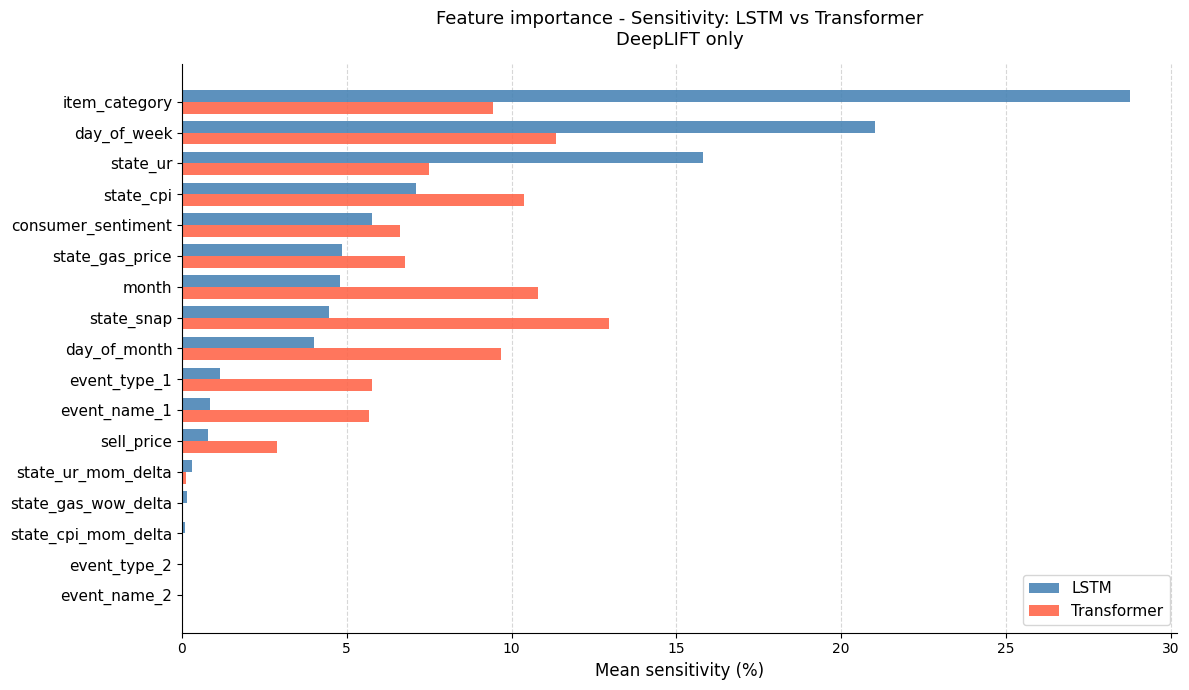

In [24]:
avg = (base.groupby(["feature", "model"])["sens_pct"].mean().reset_index())

pivot = avg.pivot(index="feature", columns="model", values="sens_pct").fillna(0)
pivot = pivot.sort_values("LSTM", ascending=True)

features = pivot.index.tolist()
lstm_vals = pivot["LSTM"].values
transformer_vals = pivot["Transformer"].values

x = np.arange(len(features))
bar_height = 0.38


fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x + bar_height / 2, lstm_vals, bar_height, color="steelblue", label="LSTM", alpha=0.88)
ax.barh(x - bar_height / 2, transformer_vals, bar_height, color="tomato", label="Transformer", alpha=0.88)

ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel("Mean sensitivity (%)", fontsize=12)
ax.set_title("Feature importance - Sensitivity: LSTM vs Transformer\nDeepLIFT only", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="lower right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
# Load interpretability analysis results for both models - LSTM and Transformer
df_lstm = pd.read_csv('../interpretability_results/LSTM_interpretability_results_v3.csv')
df_trans = pd.read_csv('../interpretability_results/Transformer_interpretability_results_v3.csv')
df_lstm_extra = pd.read_csv('../interpretability_results/LSTM_interpretability_additional_results_v3.csv')
df_trans_extra = pd.read_csv('../interpretability_results/Transformer_interpretability_additional_results_v3.csv')

df_lstm['model'] = 'LSTM'
df_lstm.insert(1, 'model', df_lstm.pop('model'))
df_lstm_extra['model'] = 'LSTM'
df_lstm_extra.insert(1, 'model', df_lstm_extra.pop('model'))

df_trans['model'] = 'Transformer'
df_trans.insert(1, 'model', df_trans.pop('model'))
df_trans_extra['model'] = 'Transformer'
df_trans_extra.insert(1, 'model', df_trans_extra.pop('model'))

df = pd.concat([df_lstm, df_trans, df_lstm_extra, df_trans_extra], ignore_index=True)

df.head(3)

,feature,model,method,sens_pct,sub_method,dir_pct,dir_abs,var_pct
0,item_category,LSTM,DeepLIFT,28.758919,base,31.202745,3.700000e-06,32.811634
1,day_of_week,LSTM,DeepLIFT,21.027088,base,-1.409894,-1.670000e-07,11.186664
2,state_ur,LSTM,DeepLIFT,15.814617,base,3.367036,3.990000e-07,17.962433


In [26]:
df.to_csv('./Interp_results.csv', index=False)
df['method'].unique()

array(['DeepLIFT', 'IntegratedGradients', 'GradientSHAP', 'DeepLIFTSHAP',
       'Saliency', 'SmoothGrad'], dtype=object)

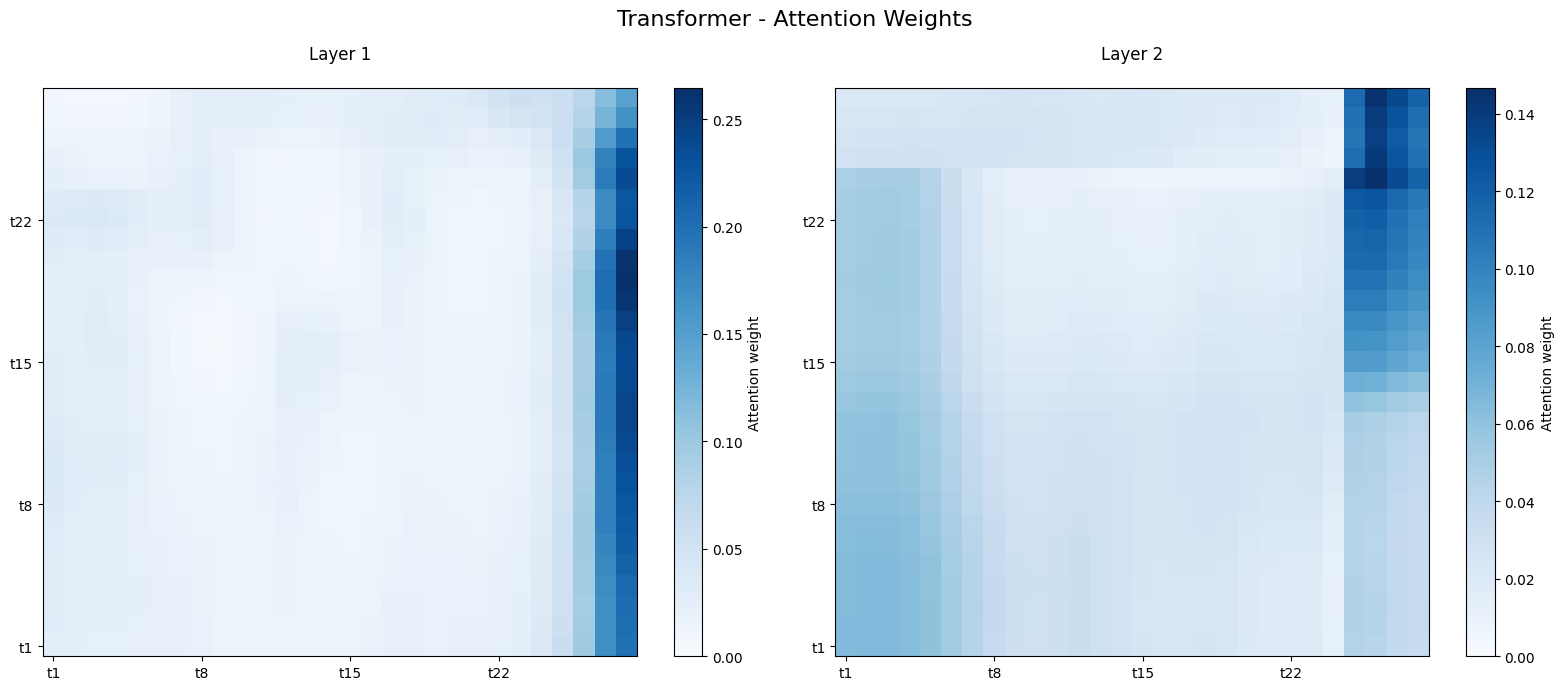

In [27]:
# Load Transformer attention weights
aw = np.load('../interpretability_results/Transformer_attention_weights.npy')
aw.shape

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Transformer - Attention Weights', fontsize=16)
for layer_idx, ax in enumerate(axes):
    avg_att = aw[layer_idx].mean(axis=0)
    
    im = ax.imshow(avg_att, cmap='Blues', aspect='auto', vmin=0, vmax=avg_att.max())
    ax.set_title(f'Layer {layer_idx + 1}\n')
    ax.set_xticks(range(0, 28, 7))
    ax.set_xticklabels([f't{i+1}' for i in range(0, 28, 7)])
    ax.set_yticks(range(0, 28, 7))
    ax.set_yticklabels([f't{i+1}' for i in range(0, 28, 7)])
    ax.invert_yaxis()
    plt.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.show()

In [28]:
lstm_temporal = np.load('../interpretability_results/LSTM_TempImp_v3.npz')
lstm_feattime = np.load('../interpretability_results/LSTM_FeatTimes_v3.npz')
trans_temporal = np.load('../interpretability_results/Transformer_TempImp_v3.npz')
trans_feattime = np.load('../interpretability_results/Transformer_FeatTimes_v3.npz')

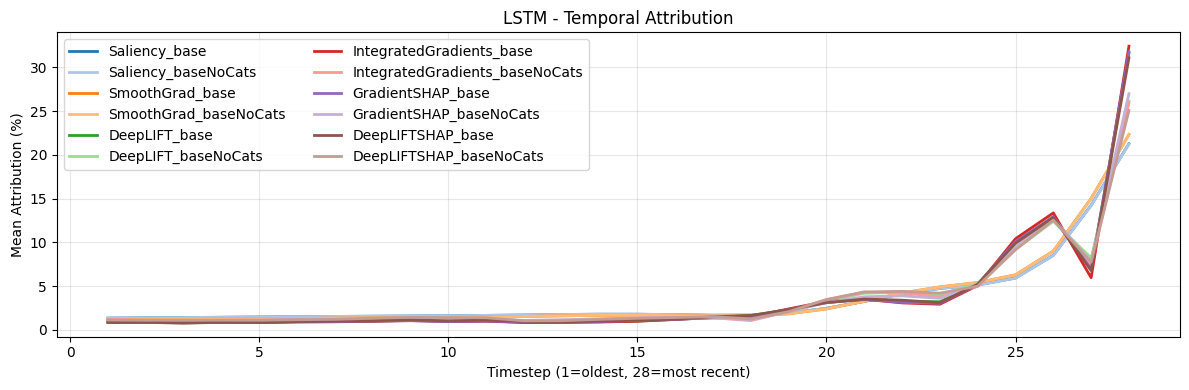

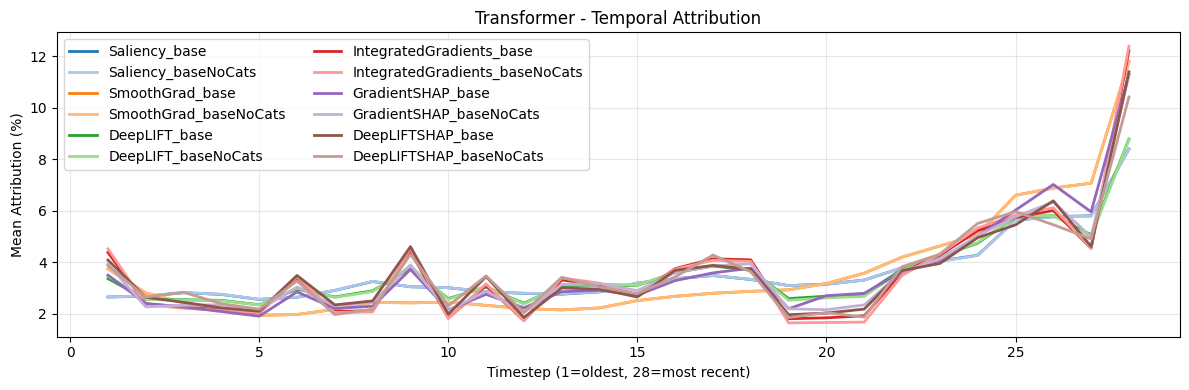

In [29]:
colors = [cm.tab20(i) for i in range(12)]

# LSTM
timesteps = np.arange(1, len(lstm_temporal['LSTM_Saliency_base']) + 1)
fig, ax = plt.subplots(figsize=(12, 4))
col_idx = 0
for i in lstm_temporal:
    ax.plot(timesteps, lstm_temporal[i], linewidth=2, color=colors[col_idx], label=i.replace('LSTM_', ''))
    col_idx += 1
ax.set_xlabel('Timestep (1=oldest, 28=most recent)')
ax.set_ylabel('Mean Attribution (%)')
ax.set_title(f'LSTM - Temporal Attribution')
ax.grid(alpha=0.3)
ax.legend(ncols=2)
ax.legend(loc='upper left', ncols=2)
plt.tight_layout()
plt.show()


# Transformer
timesteps = np.arange(1, len(trans_temporal['Transformer_Saliency_base']) + 1)
fig, ax = plt.subplots(figsize=(12, 4))
col_idx = 0
for i in trans_temporal:
    ax.plot(timesteps, trans_temporal[i], linewidth=2, color=colors[col_idx], label=i.replace('Transformer_', ''))
    col_idx += 1
ax.set_xlabel('Timestep (1=oldest, 28=most recent)')
ax.set_ylabel('Mean Attribution (%)')
ax.set_title(f'Transformer - Temporal Attribution')
ax.grid(alpha=0.3)
ax.legend(loc='upper left', ncols=2)
plt.tight_layout()
plt.show()

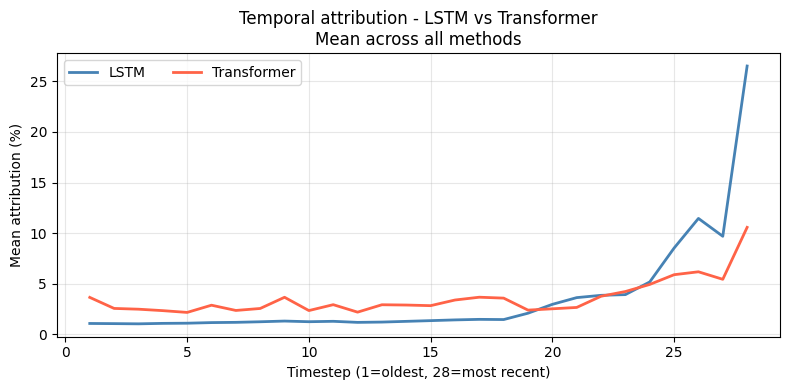

In [30]:
# Temporal attribution - Mean across all methods, LSTM vs Transformer
timesteps = np.arange(1, len(lstm_temporal['LSTM_Saliency_base']) + 1)

lstm_temporal_arr = []
for i in lstm_temporal:
    arr = np.array(lstm_temporal[i])
    lstm_temporal_arr.append(arr)
lstm_temporal_mean = np.mean(lstm_temporal_arr, axis=0)

trans_temporal_arr = []
for i in trans_temporal:
    arr = np.array(trans_temporal[i])
    trans_temporal_arr.append(arr)
trans_temporal_mean = np.mean(trans_temporal_arr, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(timesteps, lstm_temporal_mean, color='steelblue', linewidth=2, label='LSTM')
ax.plot(timesteps, trans_temporal_mean, color='tomato', linewidth=2, label='Transformer')

ax.set_xlabel('Timestep (1=oldest, 28=most recent)')
ax.set_ylabel('Mean attribution (%)')
ax.set_title(f'Temporal attribution - LSTM vs Transformer\nMean across all methods')
ax.grid(alpha=0.3)
ax.legend(ncols=2)
ax.legend(loc='upper left', ncols=2)
plt.tight_layout()
plt.show()

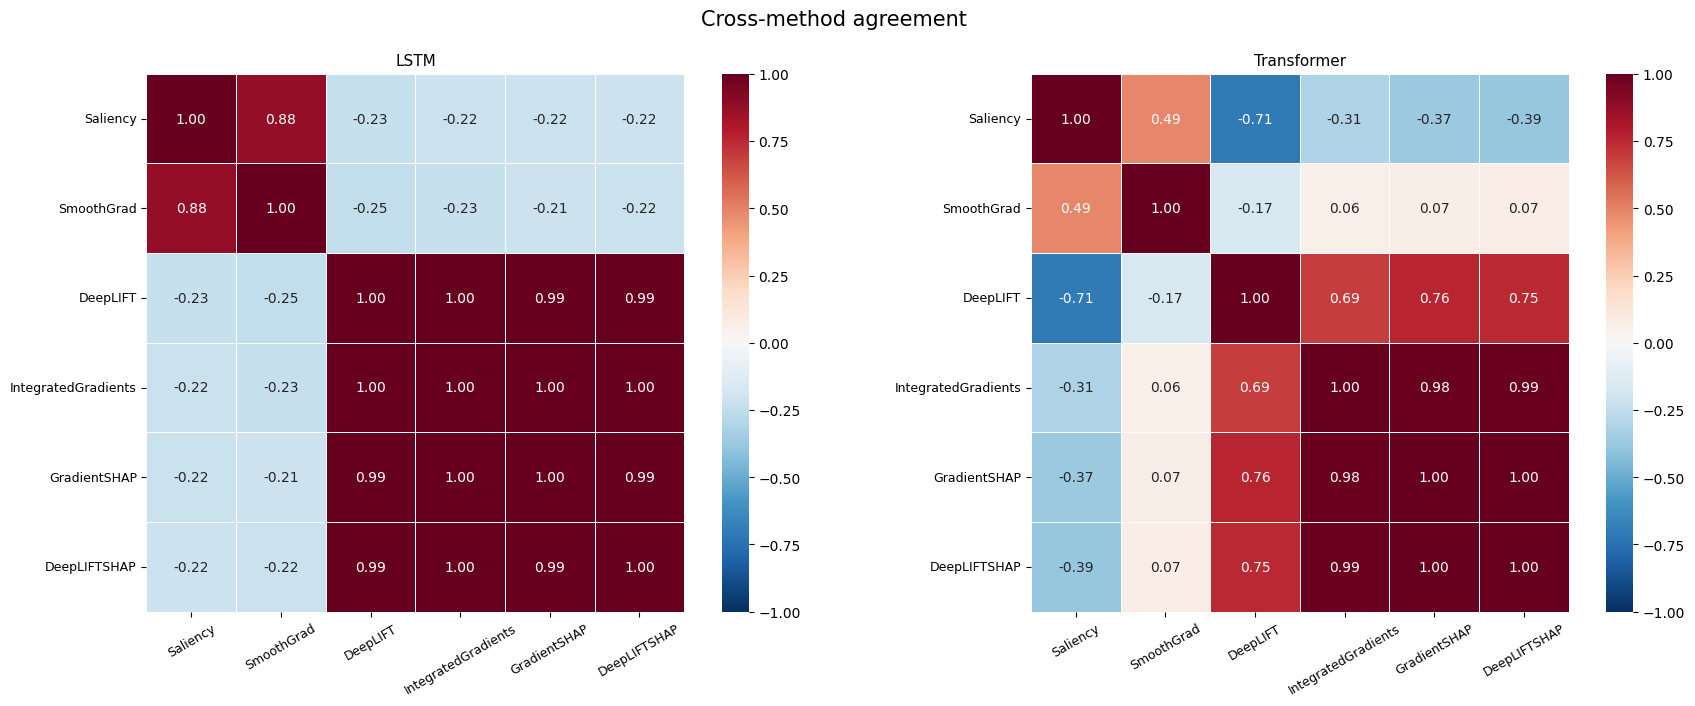

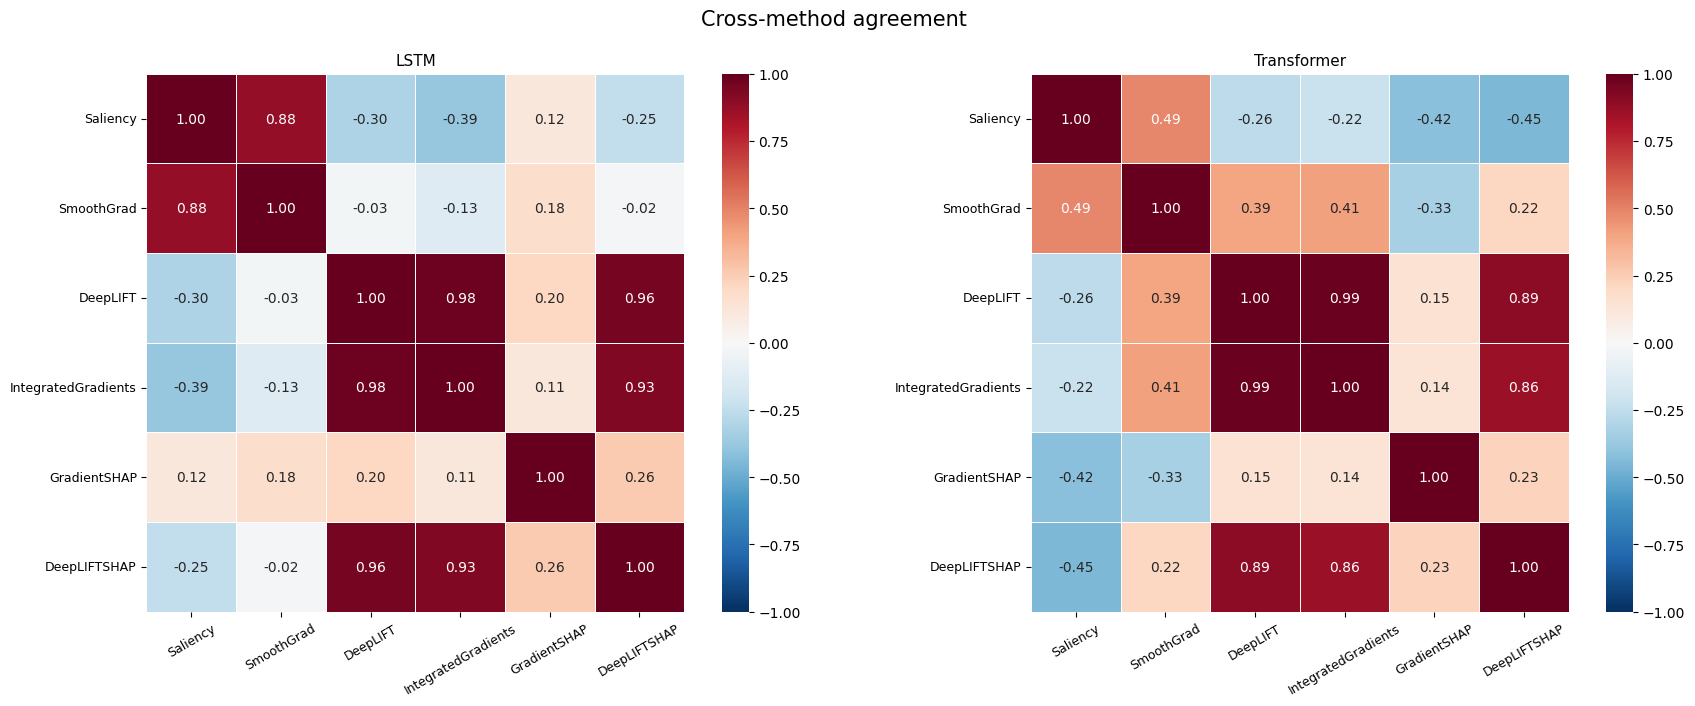

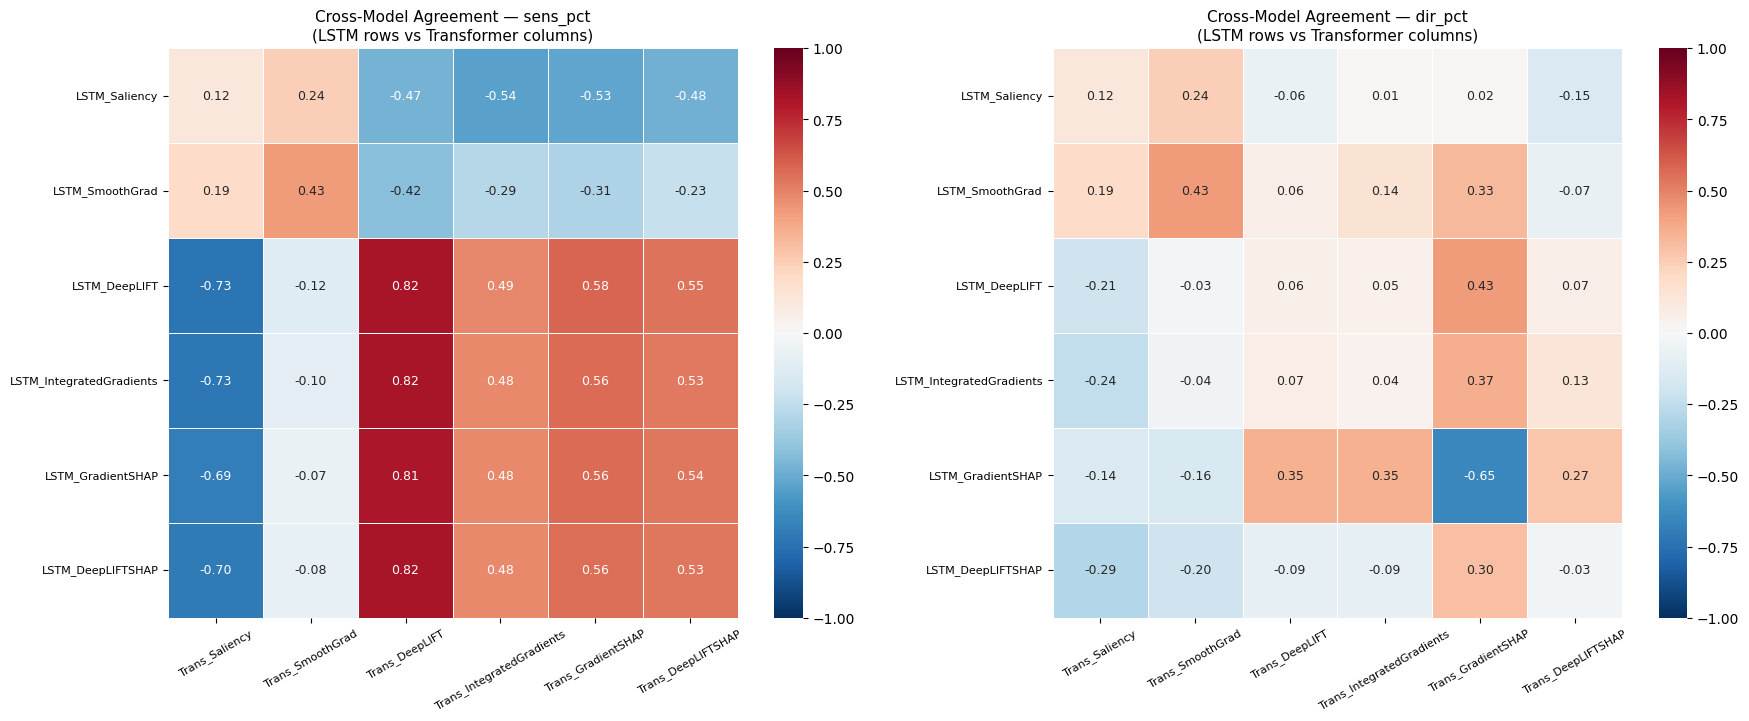

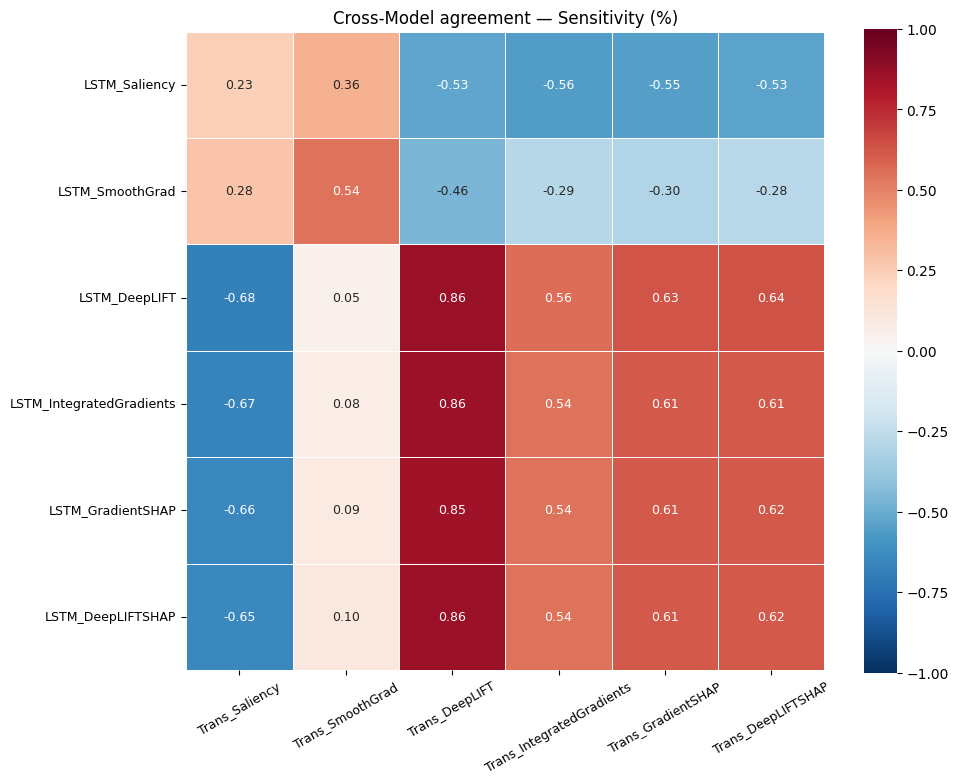

In [31]:
# Cross-method agreement
def plot_cma(feature, name):
    methods = ['Saliency', 'SmoothGrad', 'DeepLIFT', 'IntegratedGradients', 'GradientSHAP', 'DeepLIFTSHAP']
    subset = 'baseNoCats'

    rankings = {}
    for method in methods:
        mask = (df['method'] == method) & (df['sub_method'] == subset)
        if mask.sum() > 0:
            rankings[method] = df[mask].set_index('feature')[feature]

    corr_matrix = pd.DataFrame(index=rankings.keys(), columns=rankings.keys(), dtype=float)
    for m1 in rankings:
        for m2 in rankings:
            common = rankings[m1].index.intersection(rankings[m2].index)
            corr, _ = spearmanr(rankings[m1][common], rankings[m2][common])
            corr_matrix.loc[m1, m2] = round(corr, 3)


    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Cross-method agreement\n', fontsize=15)

    for ax, arch in zip(axes, ['LSTM', 'Transformer']):
        rankings = {}
        for method in methods:
            mask = (df['method'] == method) & (df['sub_method'] == subset) & (df['model'] == arch)
            if mask.sum() > 0:
                rankings[method] = df[mask].set_index('feature')[feature]

        corr_matrix = pd.DataFrame(index=rankings.keys(), columns=rankings.keys(), dtype=float)
        for m1 in rankings:
            for m2 in rankings:
                common = rankings[m1].index.intersection(rankings[m2].index)
                corr, _ = spearmanr(rankings[m1][common], rankings[m2][common])
                corr_matrix.loc[m1, m2] = round(corr, 3)

        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
                    vmin=-1, vmax=1, ax=ax, square=True,
                    linewidths=0.5, linecolor='white',
                    annot_kws={'size': 10})
        
        ax.set_title(f'{arch}', fontsize=11)
        ax.tick_params(axis='x', rotation=30, labelsize=9)
        ax.tick_params(axis='y', rotation=0, labelsize=9)

    plt.tight_layout()
    plt.show()

def plot_cmcma(metrics):
    methods = ['Saliency', 'SmoothGrad', 'DeepLIFT', 'IntegratedGradients', 'GradientSHAP', 'DeepLIFTSHAP']
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, metric in zip(axes, metrics):
        corr_matrix = pd.DataFrame(index=[f'LSTM_{m}' for m in methods], columns=[f'Trans_{m}' for m in methods], dtype=float)
        
        for m1 in methods:
            for m2 in methods:
                mask_lstm = (df['method'] == m1) & (df['sub_method'] == 'base') & (df['model'] == 'LSTM')
                mask_trans = (df['method'] == m2) & (df['sub_method'] == 'base') & (df['model'] == 'Transformer')
                
                r1 = df[mask_lstm].set_index('feature')[metric]
                r2 = df[mask_trans].set_index('feature')[metric]
                common = r1.index.intersection(r2.index)
                
                if len(common) > 3:
                    corr, _ = spearmanr(r1[common], r2[common])
                    corr_matrix.loc[f'LSTM_{m1}', f'Trans_{m2}'] = round(corr, 3)

        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
                    vmin=-1, vmax=1, ax=ax, square=True,
                    linewidths=0.5, linecolor='white',
                    annot_kws={'size': 9})
        
        ax.set_title(f'Cross-Model Agreement — {metric}\n(LSTM rows vs Transformer columns)', fontsize=11)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)

    plt.tight_layout()
    plt.show()

plot_cma('sens_pct', 'Sensitivy')
plot_cma('dir_abs', 'Directionality')

plot_cmcma(['sens_pct', 'dir_pct'])



# Cross-model agreement - Sensitivity
methods = ['Saliency', 'SmoothGrad', 'DeepLIFT', 'IntegratedGradients', 'GradientSHAP', 'DeepLIFTSHAP']
metric = 'sens_pct'

corr_matrix = pd.DataFrame(index=[f'LSTM_{m}' for m in methods], columns=[f'Trans_{m}' for m in methods], dtype=float)

for m1 in methods:
    for m2 in methods:
        mask_lstm  = (df['method'] == m1) & (df['sub_method'] == 'baseNoCats') & (df['model'] == 'LSTM')
        mask_trans = (df['method'] == m2) & (df['sub_method'] == 'baseNoCats') & (df['model'] == 'Transformer')

        r1 = df[mask_lstm].set_index('feature')[metric]
        r2 = df[mask_trans].set_index('feature')[metric]
        common = r1.index.intersection(r2.index)

        if len(common) > 3:
            corr, _ = spearmanr(r1[common], r2[common])
            corr_matrix.loc[f'LSTM_{m1}', f'Trans_{m2}'] = round(corr, 3)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})

ax.set_title('Cross-Model agreement — Sensitivity (%)', fontsize=12)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

In [32]:
print(lstm_feattime)
print(trans_feattime)

NpzFile '../interpretability_results/LSTM_FeatTimes_v3.npz' with keys: LSTM_Saliency_base, LSTM_Saliency_baseNoCats, LSTM_SmoothGrad_base, LSTM_SmoothGrad_baseNoCats, LSTM_DeepLIFT_base...
NpzFile '../interpretability_results/Transformer_FeatTimes_v3.npz' with keys: Transformer_Saliency_base, Transformer_Saliency_baseNoCats, Transformer_SmoothGrad_base, Transformer_SmoothGrad_baseNoCats, Transformer_DeepLIFT_base...


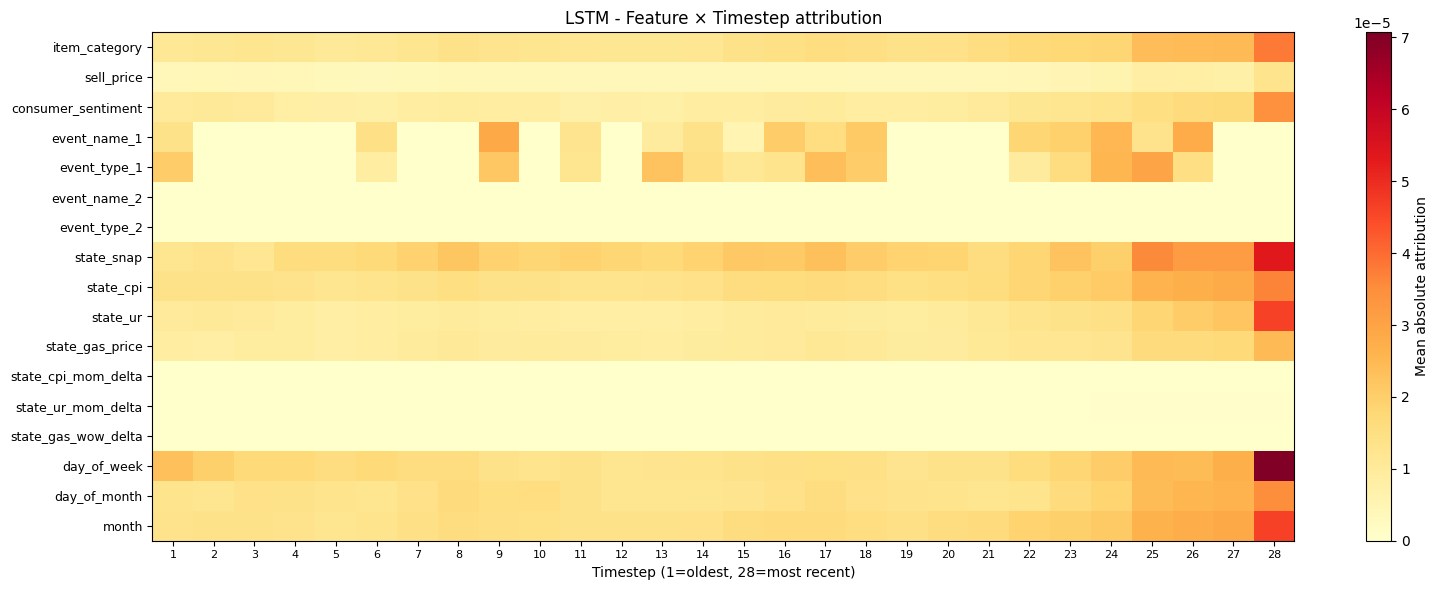

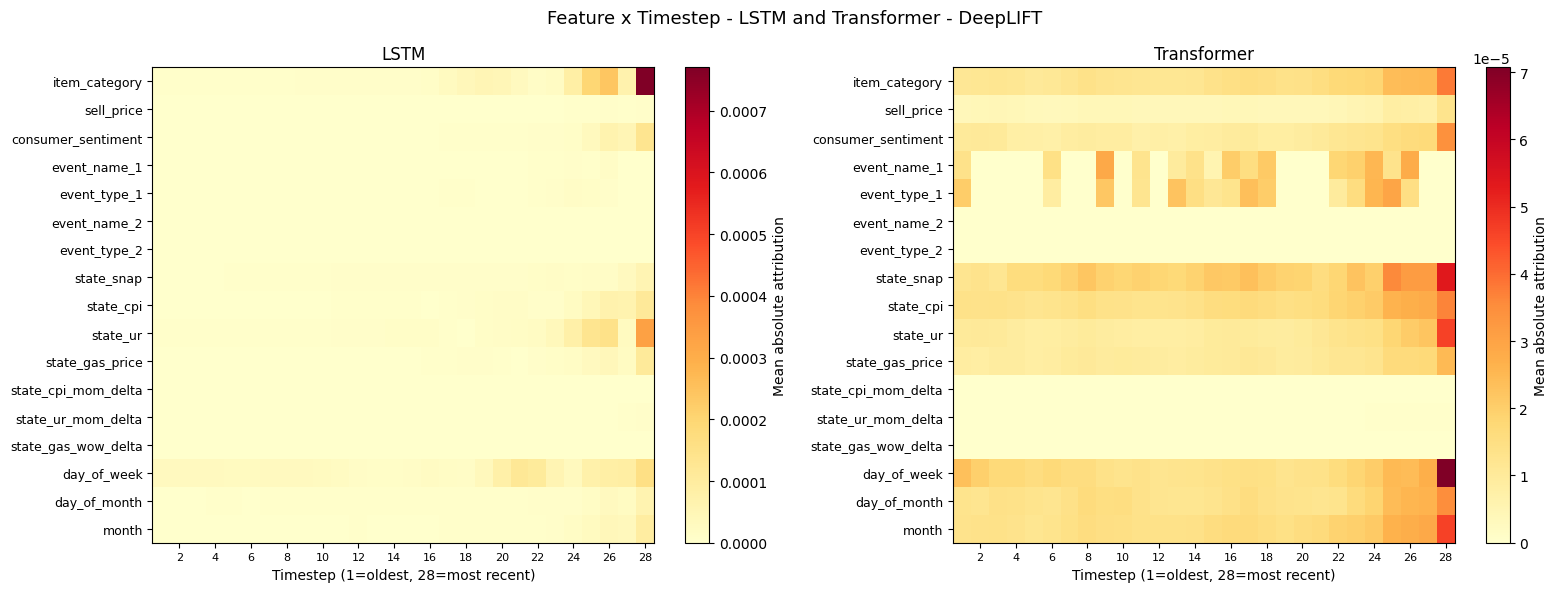

In [33]:
# Feature x Timestep
feature_cols = [
    'units_sold',
    'item_id', 'store_id', 'item_category', 'sell_price','consumer_sentiment',
    'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'state_snap',
    'state_cpi', 'state_ur', 'state_gas_price',
    'state_cpi_mom_delta', 'state_ur_mom_delta', 'state_gas_wow_delta',
    'day_of_week', 'day_of_month', 'month', 'year'
]
exclude_cols_base = ['units_sold', 'item_id', 'store_id', 'year']
exclude_cols_base_no_cats = ['units_sold', 'item_id', 'store_id', 'year']
INTERP_COLS = [c for c in feature_cols if c not in exclude_cols_base]
FORECAST_HORIZON = 28

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(trans_feattime['Transformer_DeepLIFT_base'].T, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(INTERP_COLS)))
ax.set_yticklabels(INTERP_COLS, fontsize=9)
ax.set_xticks(range(FORECAST_HORIZON))
ax.set_xticklabels(range(1, FORECAST_HORIZON + 1), fontsize=8)
ax.set_xlabel('Timestep (1=oldest, 28=most recent)')
ax.set_title(f'LSTM - Feature × Timestep attribution')
plt.colorbar(im, label='Mean absolute attribution')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle('Feature x Timestep - LSTM and Transformer - DeepLIFT', fontsize=13)

im1 = ax1.imshow(lstm_feattime['LSTM_DeepLIFT_base'].T, aspect='auto', cmap='YlOrRd')
ax1.set_yticks(range(len(INTERP_COLS)))
ax1.set_yticklabels(INTERP_COLS, fontsize=9)
ax1.set_xticks(range(1, FORECAST_HORIZON, 2))
ax1.set_xticklabels(range(2, FORECAST_HORIZON + 1, 2), fontsize=8)
ax1.set_xlabel('Timestep (1=oldest, 28=most recent)')
ax1.set_title(f'LSTM')
plt.colorbar(im1, label='Mean absolute attribution')

im2 = ax2.imshow(trans_feattime['Transformer_DeepLIFT_base'].T, aspect='auto', cmap='YlOrRd')
ax2.set_yticks(range(len(INTERP_COLS)))
ax2.set_yticklabels(INTERP_COLS, fontsize=9)
ax2.set_xticks(range(1, FORECAST_HORIZON, 2))
ax2.set_xticklabels(range(2, FORECAST_HORIZON + 1, 2), fontsize=8)
ax2.set_xlabel('Timestep (1=oldest, 28=most recent)')
ax2.set_title(f'Transformer')
plt.colorbar(im2, label='Mean absolute attribution')

plt.tight_layout()
plt.show()


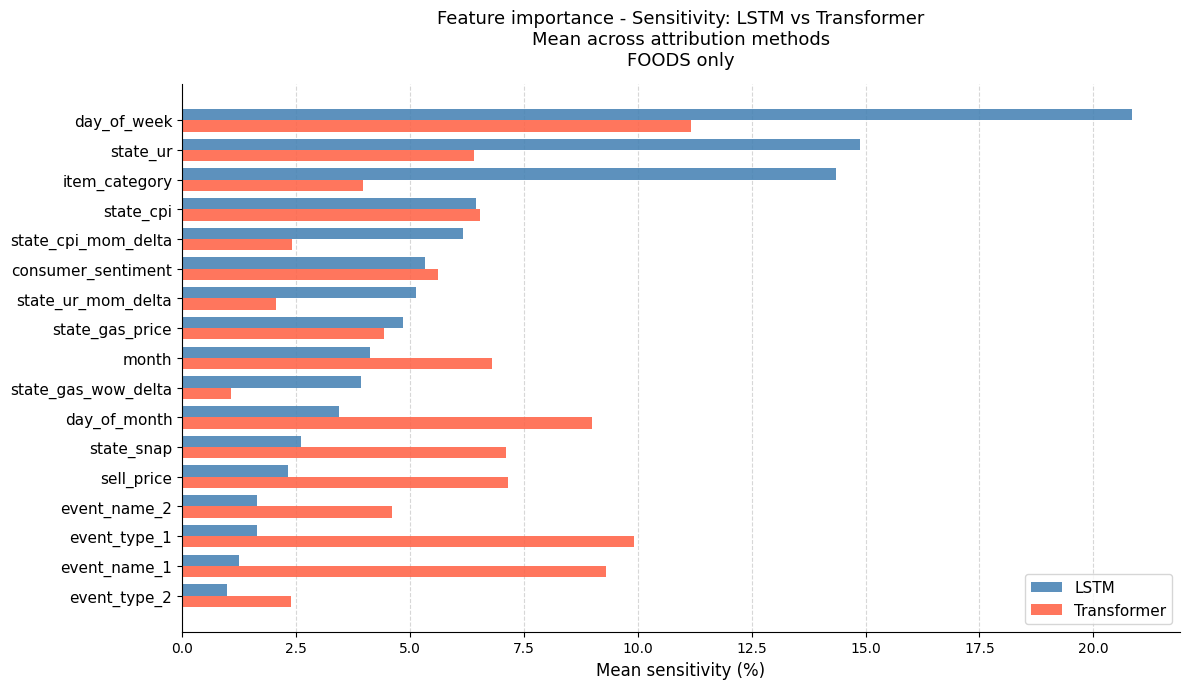

In [34]:
base = df[df["sub_method"] == "HOUSEHOLD"].copy()
avg = (base.groupby(["feature", "model"])["sens_pct"].mean().reset_index())

pivot = avg.pivot(index="feature", columns="model", values="sens_pct").fillna(0)
pivot = pivot.sort_values("LSTM", ascending=True)

features = pivot.index.tolist()
lstm_vals = pivot["LSTM"].values
transformer_vals = pivot["Transformer"].values

x = np.arange(len(features))
bar_height = 0.38



fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x + bar_height / 2, lstm_vals, bar_height, color="steelblue", label="LSTM", alpha=0.88)
ax.barh(x - bar_height / 2, transformer_vals, bar_height, color="tomato", label="Transformer", alpha=0.88)

ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel("Mean sensitivity (%)", fontsize=12)
ax.set_title("Feature importance - Sensitivity: LSTM vs Transformer\nMean across attribution methods\nFOODS only", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="lower right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

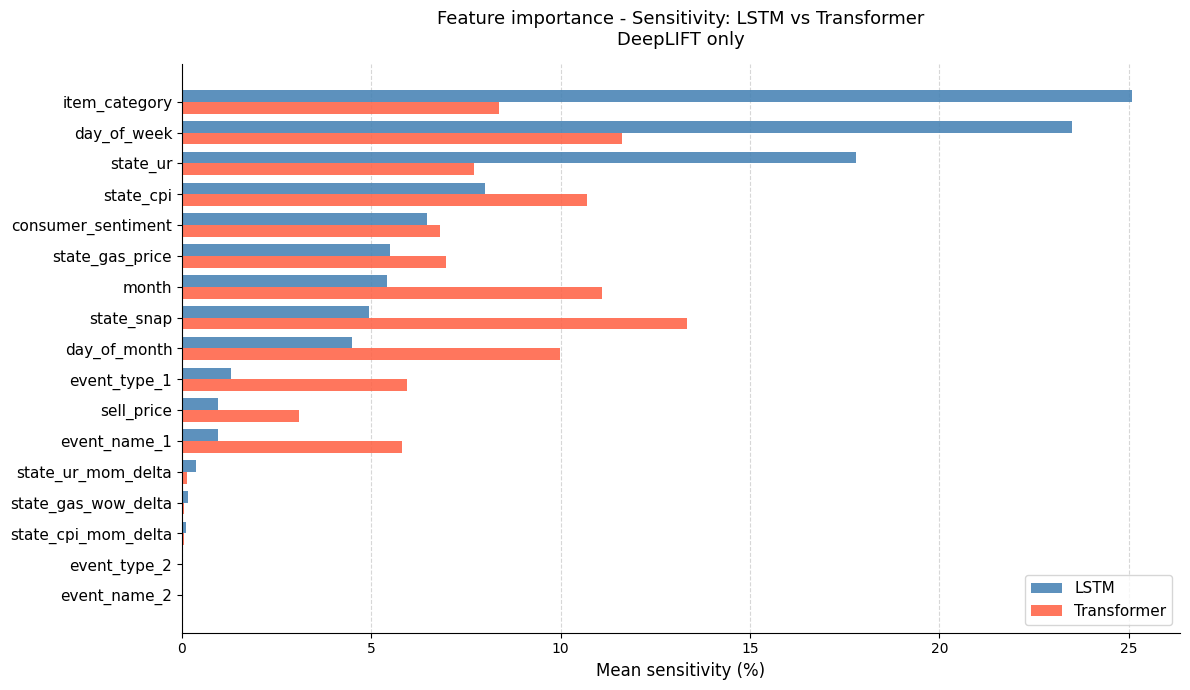

In [35]:
base = df[df['method'] == "DeepLIFT"].copy()
avg = (base.groupby(["feature", "model"])["sens_pct"].mean().reset_index())

pivot = avg.pivot(index="feature", columns="model", values="sens_pct").fillna(0)
pivot = pivot.sort_values("LSTM", ascending=True)

features = pivot.index.tolist()
lstm_vals = pivot["LSTM"].values
transformer_vals = pivot["Transformer"].values

x = np.arange(len(features))
bar_height = 0.38


fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x + bar_height / 2, lstm_vals, bar_height, color="steelblue", label="LSTM", alpha=0.88)
ax.barh(x - bar_height / 2, transformer_vals, bar_height, color="tomato", label="Transformer", alpha=0.88)

ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel("Mean sensitivity (%)", fontsize=12)
ax.set_title("Feature importance - Sensitivity: LSTM vs Transformer\nDeepLIFT only", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="lower right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

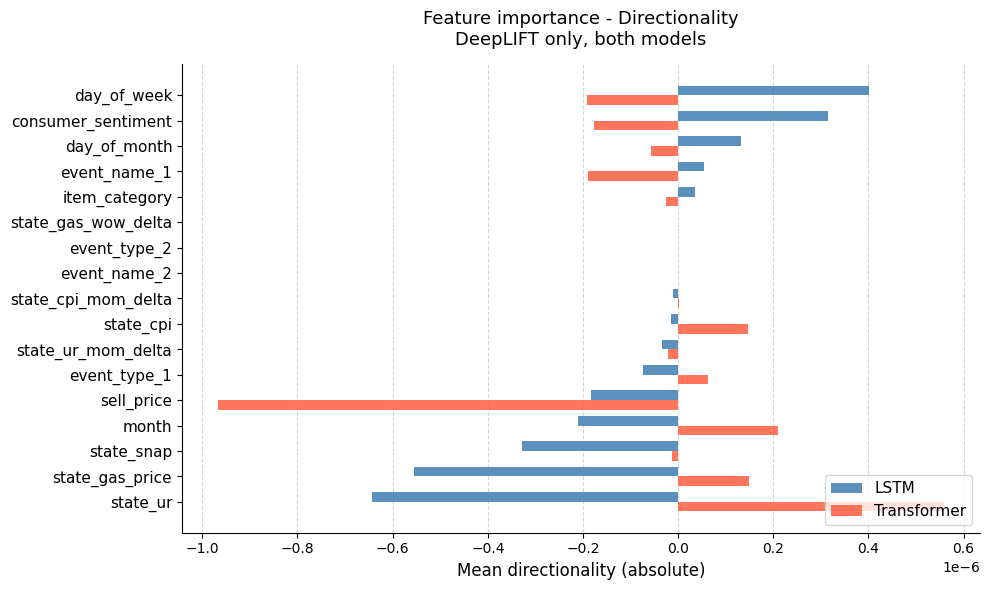

In [36]:
df = pd.read_csv("./Interp_results.csv")

base = df[(df['method'] == "GradientSHAP") & (df["sub_method"] == "base")].copy()
avg = (base.groupby(["feature", "model"])["dir_abs"].mean().reset_index())

pivot = avg.pivot(index="feature", columns="model", values="dir_abs").fillna(0)
pivot = pivot.sort_values("LSTM", ascending=True)

features = pivot.index.tolist()
lstm_vals = pivot["LSTM"].values
transformer_vals = pivot["Transformer"].values

x = np.arange(len(features))
bar_height = 0.38


fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(x + bar_height / 2, lstm_vals, bar_height, color="steelblue", label="LSTM", alpha=0.88)
ax.barh(x - bar_height / 2, transformer_vals, bar_height, color="tomato", label="Transformer", alpha=0.88)

ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel("Mean directionality (absolute)", fontsize=12)
ax.set_title("Feature importance - Directionality\nDeepLIFT only, both models", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="lower right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

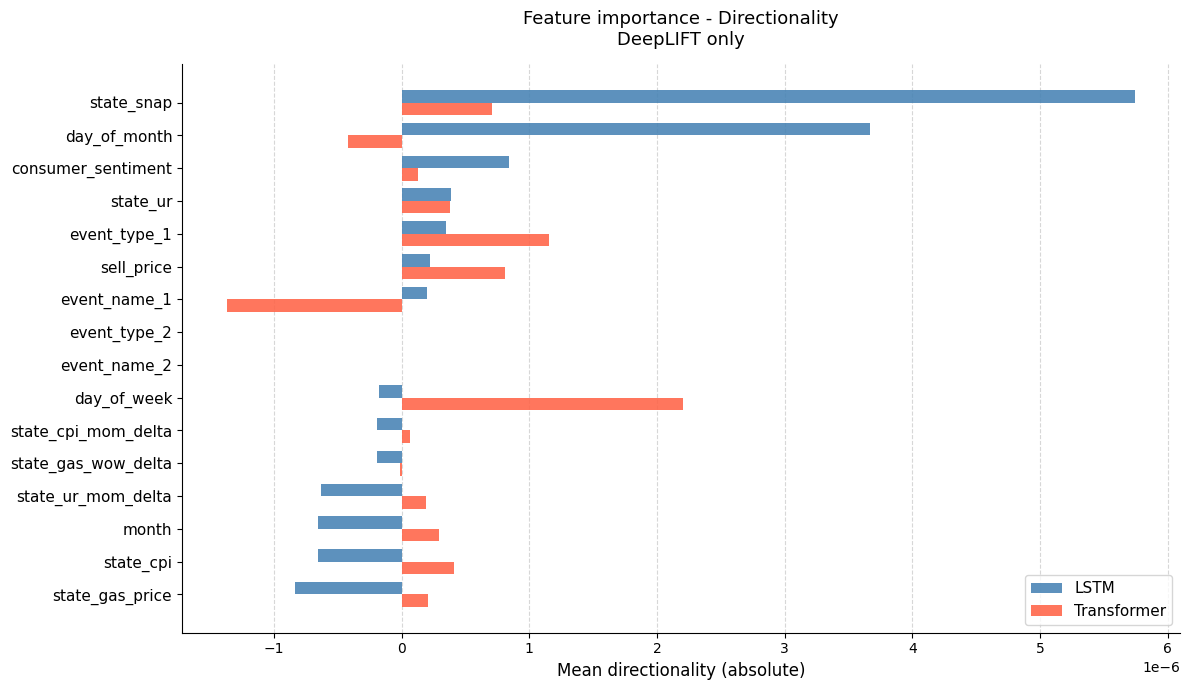

In [37]:
base = df[(df['method'] == "DeepLIFT") & (df["sub_method"] == "baseNoCats")].copy()
avg = (base.groupby(["feature", "model"])["dir_abs"].mean().reset_index())

pivot = avg.pivot(index="feature", columns="model", values="dir_abs").fillna(0)
pivot = pivot.sort_values("LSTM", ascending=True)

features = pivot.index.tolist()
lstm_vals = pivot["LSTM"].values
transformer_vals = pivot["Transformer"].values

x = np.arange(len(features))
bar_height = 0.38


fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x + bar_height / 2, lstm_vals, bar_height, color="steelblue", label="LSTM", alpha=0.88)
ax.barh(x - bar_height / 2, transformer_vals, bar_height, color="tomato", label="Transformer", alpha=0.88)

ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel("Mean directionality (absolute)", fontsize=12)
ax.set_title("Feature importance - Directionality\nDeepLIFT only", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="lower right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

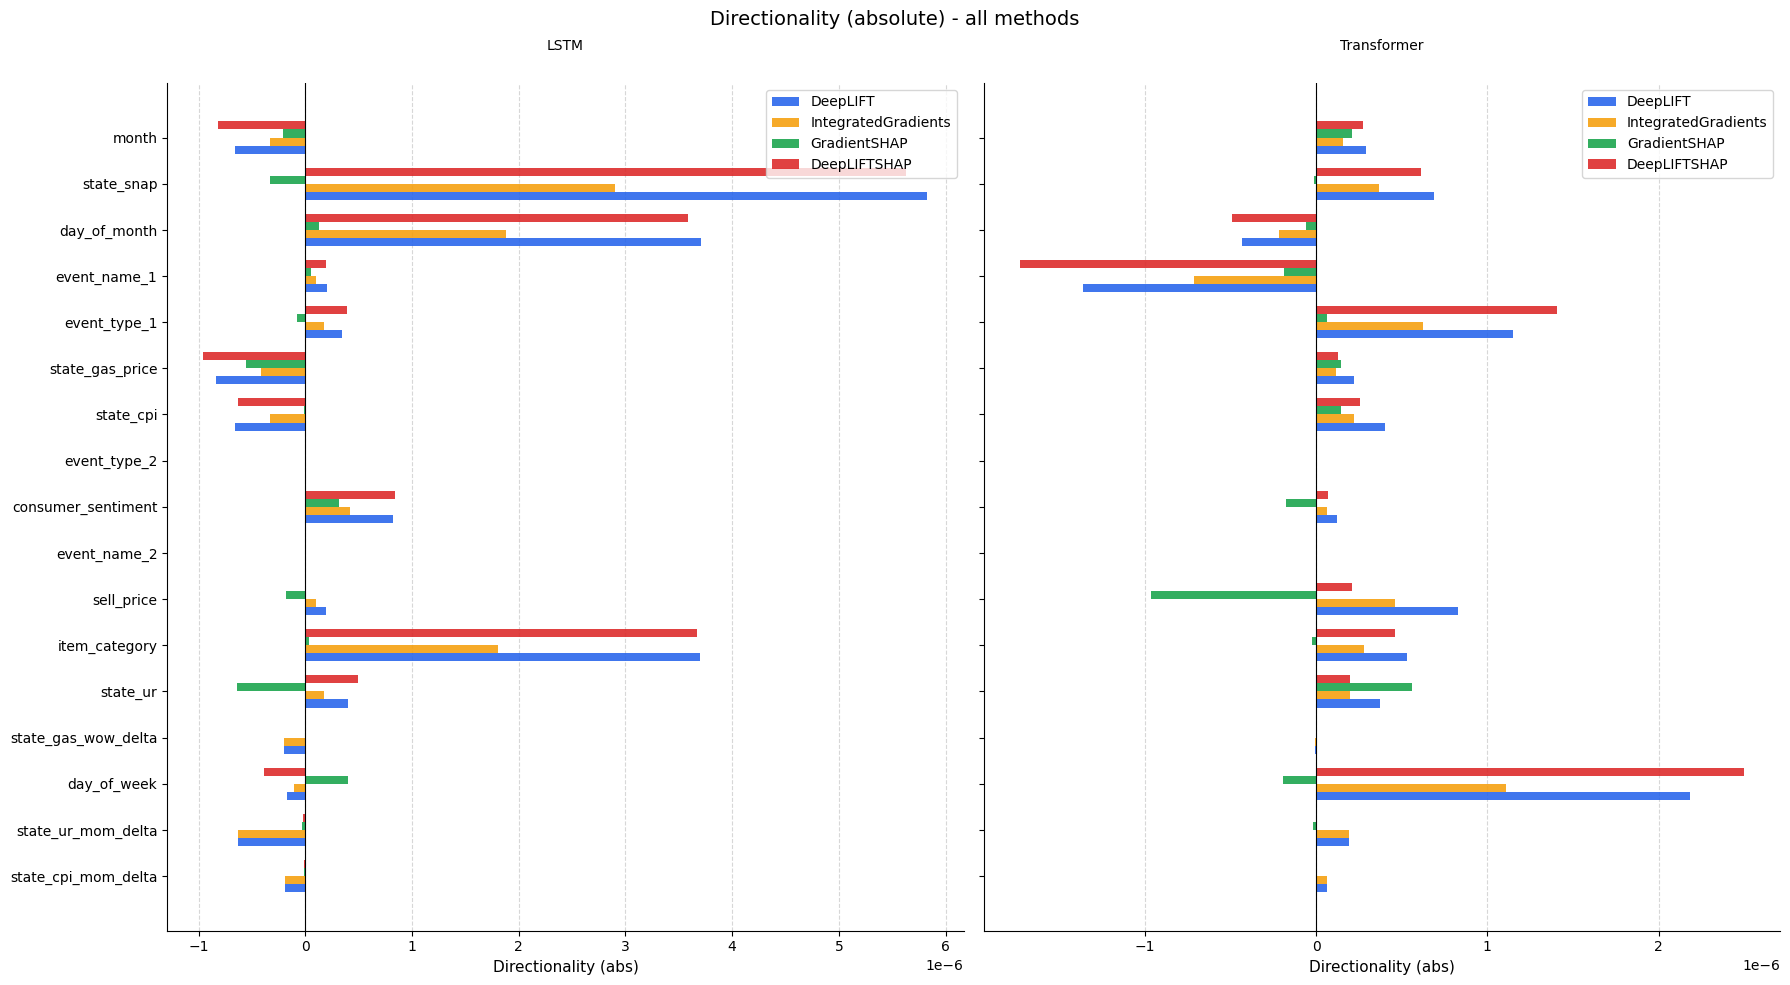

In [38]:
methods = ['DeepLIFT', 'IntegratedGradients', 'GradientSHAP', 'DeepLIFTSHAP']
method_colors = {
    method: color for method, color in zip(methods, [
        "#2563EB", "#F59E0B", "#16A34A", "#DC2626", "#7C3AED", "#0891B2"
    ])
}

feature_order = (
    df[df["model"] == "LSTM"]
    .groupby("feature")["dir_abs"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

def plot_directionality_methods(model_name, feature_order, ax):
    data = df[(df["model"] == model_name) & (df["sub_method"] == "base")].copy()
    
    data = (data.groupby(["feature", "method"])["dir_abs"].mean().reset_index())
    
    n_features = len(feature_order)
    n_methods = len(methods)
    bar_height = 0.7 / n_methods
    x = np.arange(n_features)

    for i, method in enumerate(methods):
        method_vals = (data[data["method"] == method].set_index("feature")["dir_abs"])
        vals = [float(method_vals.get(f, 0)) for f in feature_order]
        offset = (i - n_methods / 2 + 0.5) * bar_height
        ax.barh(x + offset, vals, bar_height, color=method_colors[method], label=method, alpha=0.88)

    ax.set_yticks(x)
    ax.set_yticklabels(feature_order, fontsize=10)
    ax.set_xlabel("Directionality (abs)", fontsize=11)
    ax.set_title(f"{model_name}\n", fontsize=10, pad=12)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.legend(fontsize=10, loc="upper right")
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)
fig.suptitle("Directionality (absolute) - all methods", fontsize=14)
plot_directionality_methods("LSTM", feature_order, axes[0])
plot_directionality_methods("Transformer", feature_order, axes[1])

plt.tight_layout()
plt.show()

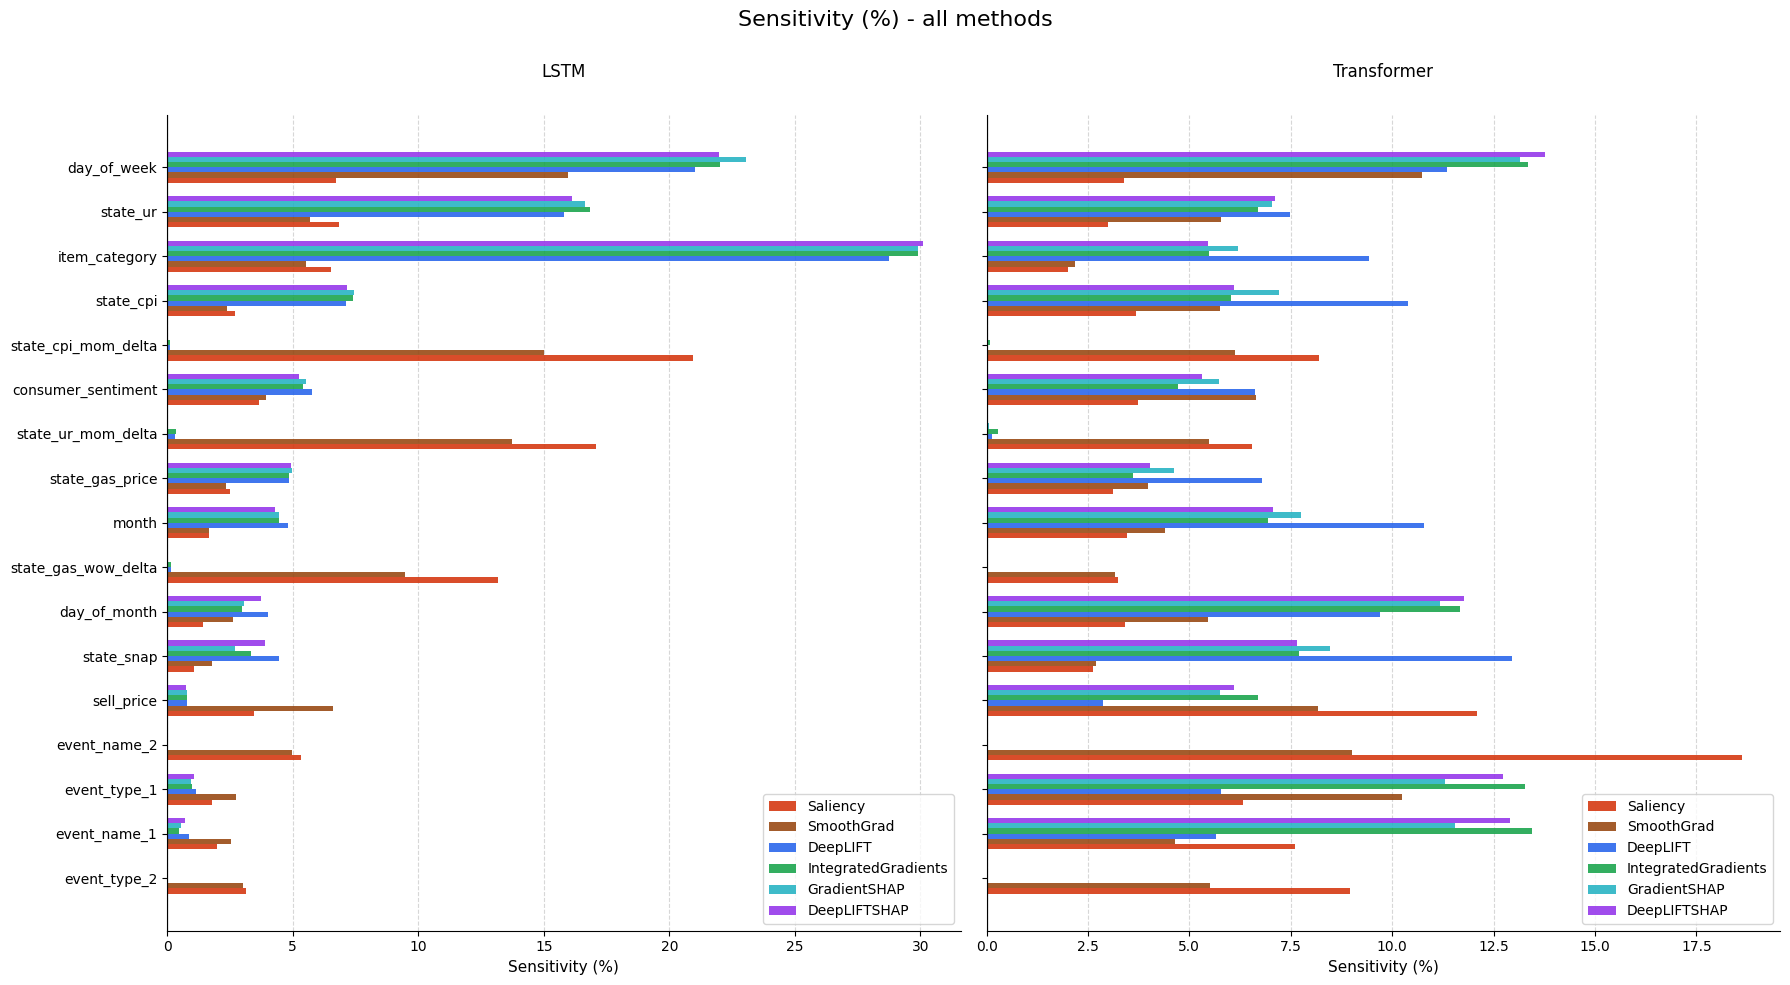

In [39]:
methods = ['Saliency', 'SmoothGrad', 'DeepLIFT', 'IntegratedGradients', 'GradientSHAP', 'DeepLIFTSHAP']
method_colors = {
    "Saliency":            "#D4340C",
    "SmoothGrad":          "#96450F",
    "DeepLIFT":           "#2563EB",
    "IntegratedGradients": "#16A34A",
    "GradientSHAP":        "#23B2C2",
    "DeepLIFTSHAP":        "#9333EA"
}

feature_order = (
    df[df["model"] == "LSTM"]
    .groupby("feature")["sens_pct"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

def plot_directionality_methods(model_name, feature_order, ax):
    data = df[(df["model"] == model_name) & (df["sub_method"] == "base")].copy()
    
    data = (data.groupby(["feature", "method"])["sens_pct"].mean().reset_index())
    
    n_features = len(feature_order)
    n_methods = len(methods)
    bar_height = 0.7 / n_methods
    x = np.arange(n_features)

    for i, method in enumerate(methods):
        method_vals = (data[data["method"] == method].set_index("feature")["sens_pct"])
        vals = [float(method_vals.get(f, 0)) for f in feature_order]
        offset = (i - n_methods / 2 + 0.5) * bar_height
        ax.barh(x + offset, vals, bar_height, color=method_colors[method], label=method, alpha=0.88)

    ax.set_yticks(x)
    ax.set_yticklabels(feature_order, fontsize=10)
    ax.set_xlabel("Sensitivity (%)", fontsize=11)
    ax.set_title(f"{model_name}\n",fontsize=12, pad=12)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.legend(fontsize=10, loc="lower right")
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)
fig.suptitle("Sensitivity (%) - all methods\n", fontsize=16)
plot_directionality_methods("LSTM", feature_order, axes[0])
plot_directionality_methods("Transformer", feature_order, axes[1])

plt.tight_layout()
plt.show()

In [40]:
# Comparison of different item categories effect on sensitivity - DeepLIFT, both models
# Answers the question - do different item categories affect the sensitivity rating differently?

df_cats = df[(df['method'] == "DeepLIFT") & (df['sub_method'] != "baseNoCats")]

print(df_cats[((df_cats['model'] == 'LSTM') & (df_cats['sub_method'] == 'FOODS') & (df_cats['feature'] == 'item_category'))]['sens_pct'])
print(df_cats[((df_cats['model'] == 'Transformer') & (df_cats['sub_method'] == 'FOODS') & (df_cats['feature'] == 'item_category'))]['sens_pct'])

33    29.66759
Name: sens_pct, dtype: float64
373    10.138244
Name: sens_pct, dtype: float64


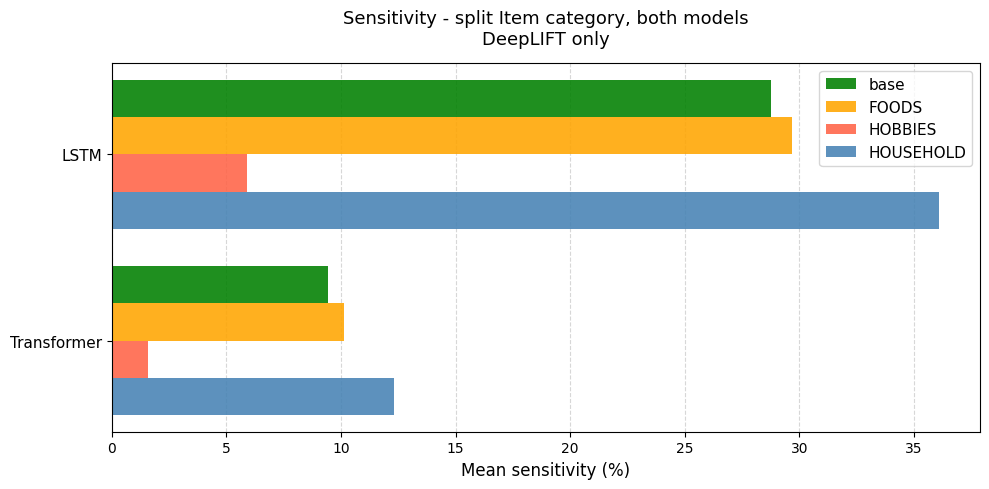

In [41]:
data = df_cats[(df_cats['feature'] == 'item_category') & (df_cats['sub_method'].isin(['base', 'FOODS', 'HOBBIES', 'HOUSEHOLD']))].copy()

models = ['LSTM', 'Transformer']
categories = ['base', 'FOODS', 'HOBBIES', 'HOUSEHOLD']
colors = {'base': 'green', 'FOODS': 'orange', 'HOBBIES': 'tomato', 'HOUSEHOLD': 'steelblue'}

n_models = len(models)
n_cats = len(categories)
bar_height = 0.2
x = np.arange(n_models)

fig, ax = plt.subplots(figsize=(10, 5))

for i, cat in enumerate(categories):
    offset = (i - n_cats / 2 + 0.5) * bar_height
    vals = [data[(data['model'] == m) & (data['sub_method'] == cat)]['sens_pct'].mean() for m in models]
    ax.barh(x + offset, vals, bar_height, color=colors[cat], label=cat, alpha=0.88)

ax.invert_yaxis()
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=11)
ax.set_xlabel("Mean sensitivity (%)", fontsize=12)
ax.set_title("Sensitivity - split Item category, both models\nDeepLIFT only", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="upper right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

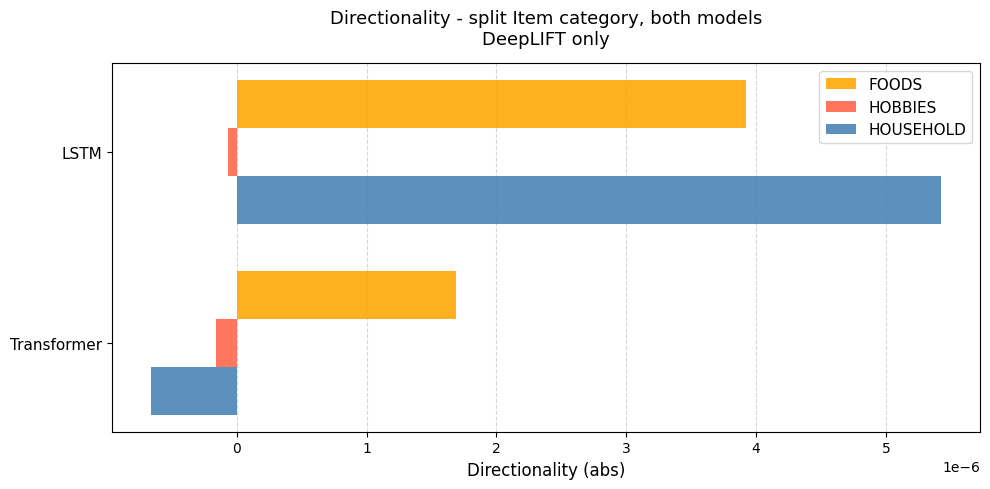

In [42]:
data = df_cats[(df_cats['feature'] == 'item_category') & (df_cats['sub_method'].isin(['FOODS', 'HOBBIES', 'HOUSEHOLD']))].copy()

models = ['LSTM', 'Transformer']
categories = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
colors = {'FOODS': 'orange', 'HOBBIES': 'tomato', 'HOUSEHOLD': 'steelblue'}

n_models = len(models)
n_cats = len(categories)
bar_height = 0.25
x = np.arange(n_models)

fig, ax = plt.subplots(figsize=(10, 5))

for i, cat in enumerate(categories):
    offset = (i - n_cats / 2 + 0.5) * bar_height
    vals = [data[(data['model'] == m) & (data['sub_method'] == cat)]['dir_abs'].mean() for m in models]
    ax.barh(x + offset, vals, bar_height, color=colors[cat], label=cat, alpha=0.88)

ax.invert_yaxis()
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=11)
ax.set_xlabel("Directionality (abs)", fontsize=12)
ax.set_title("Directionality - split Item category, both models\nDeepLIFT only", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="upper right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

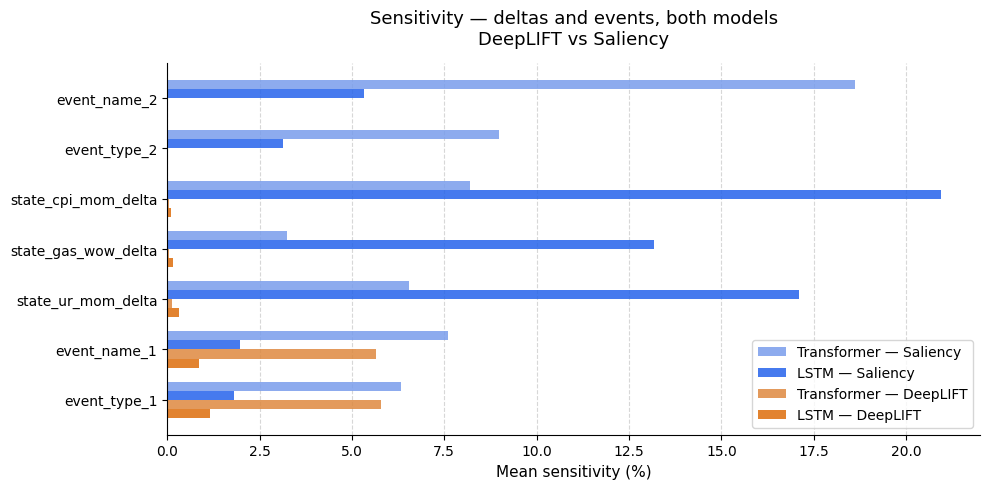

In [43]:
values_to_show = ['event_type_1', 'event_name_1', 'state_ur_mom_delta','state_gas_wow_delta', 'state_cpi_mom_delta', 'event_name_2', 'event_type_2']

methods_to_plot = ['Saliency', 'DeepLIFT']
models = ['LSTM', 'Transformer']

colors = {
    ('LSTM',        'DeepLIFT'):  "#DD6D0C",
    ('Transformer', 'DeepLIFT'):  "#DE893F",
    ('LSTM',        'Saliency'):  "#2563EB",
    ('Transformer', 'Saliency'):  "#799DEC",
}
hatches = {
    'DeepLIFT': '',
    'Saliency':  '///',
}

df_subset = df[
    (df['method'].isin(methods_to_plot)) &
    (df['sub_method'] == 'base') &
    (df['feature'].isin(values_to_show))
].copy()

feature_order = (
    df_subset[(df_subset['model'] == 'LSTM') & (df_subset['method'] == 'DeepLIFT')]
    .groupby('feature')['sens_pct']
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

combos = [
    ('LSTM',        'DeepLIFT'),
    ('Transformer', 'DeepLIFT'),
    ('LSTM',        'Saliency'),
    ('Transformer', 'Saliency'),
]

n_features = len(feature_order)
n_combos   = len(combos)
bar_height = 0.18
x = np.arange(n_features)

fig, ax = plt.subplots(figsize=(10, 5))

for i, (model, method) in enumerate(reversed(combos)):
    offset = (i - n_combos / 2 + 0.5) * bar_height
    vals = [
        df_subset[
            (df_subset['model']  == model) &
            (df_subset['method'] == method) &
            (df_subset['feature'] == f)
        ]['sens_pct'].mean()
        for f in feature_order]
    
    ax.barh(x + offset, vals, bar_height, color=colors[(model, method)], alpha=0.85, label=f'{model} — {method}')

ax.invert_yaxis()
ax.set_yticks(x)
ax.set_yticklabels(feature_order, fontsize=10)
ax.set_xlabel('Mean sensitivity (%)', fontsize=11)
ax.set_title('Sensitivity — deltas and events, both models\nDeepLIFT vs Saliency', fontsize=13, pad=14)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

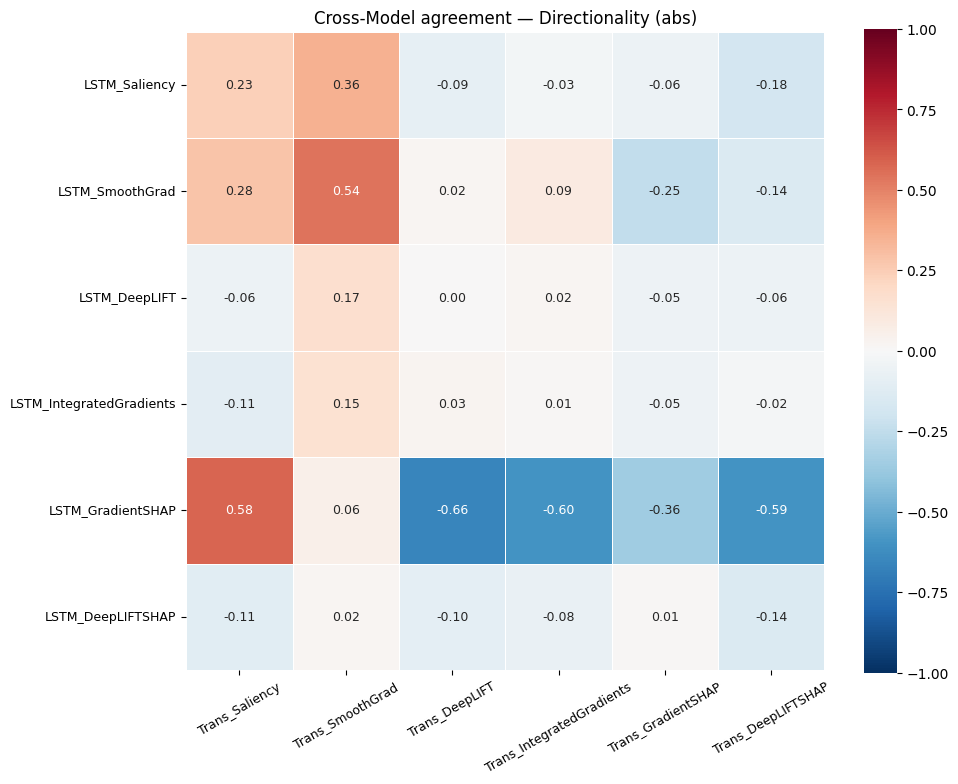

In [44]:
# Cross-model agreement - directionality
methods = ['Saliency', 'SmoothGrad', 'DeepLIFT', 'IntegratedGradients', 'GradientSHAP', 'DeepLIFTSHAP']
metric = 'dir_abs'

corr_matrix = pd.DataFrame(index=[f'LSTM_{m}' for m in methods], columns=[f'Trans_{m}' for m in methods],dtype=float)

for m1 in methods:
    for m2 in methods:
        mask_lstm  = (df['method'] == m1) & (df['sub_method'] == 'baseNoCats') & (df['model'] == 'LSTM')
        mask_trans = (df['method'] == m2) & (df['sub_method'] == 'baseNoCats') & (df['model'] == 'Transformer')

        r1 = df[mask_lstm].set_index('feature')[metric]
        r2 = df[mask_trans].set_index('feature')[metric]
        common = r1.index.intersection(r2.index)

        if len(common) > 3:
            corr, _ = spearmanr(r1[common], r2[common])
            corr_matrix.loc[f'LSTM_{m1}', f'Trans_{m2}'] = round(corr, 3)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})

ax.set_title('Cross-Model agreement — Directionality (abs)', fontsize=12)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

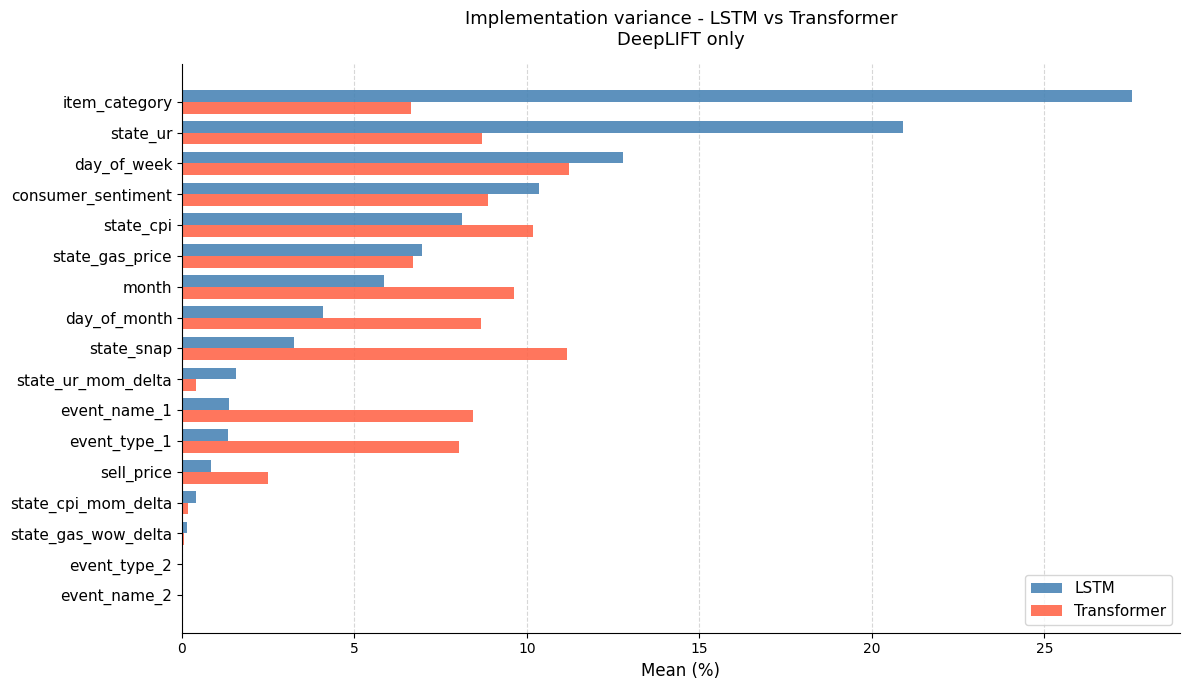

In [45]:
base = df[df['method'] == "DeepLIFT"].copy()
avg = (base.groupby(["feature", "model"])["var_pct"].mean().reset_index())

pivot = avg.pivot(index="feature", columns="model", values="var_pct").fillna(0)
pivot = pivot.sort_values("LSTM", ascending=True)

features = pivot.index.tolist()
lstm_vals = pivot["LSTM"].values
transformer_vals = pivot["Transformer"].values

x = np.arange(len(features))
bar_height = 0.38


fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x + bar_height / 2, lstm_vals, bar_height, color="steelblue", label="LSTM", alpha=0.88)
ax.barh(x - bar_height / 2, transformer_vals, bar_height, color="tomato", label="Transformer", alpha=0.88)

ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=11)
ax.set_xlabel("Mean (%)", fontsize=12)
ax.set_title("Implementation variance - LSTM vs Transformer\nDeepLIFT only", fontsize=13, pad=14)
ax.legend(fontsize=11, loc="lower right")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()